<a href="https://colab.research.google.com/github/sonjoy1s/Kaggle_Deep_Lr/blob/main/ICU_Patient_Monitoring_%26_Mortality_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset


In [56]:
torch.manual_seed(42)

In [57]:
# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [58]:
df = pd.read_csv('/content/ICU_Patient_Monitoring_Mortality_Prediction_15000.csv')
df.head()

,patient_id,age,gender,admission_type,comorbidity_score,heart_rate_mean,heart_rate_std,heart_rate_max,heart_rate_min,systolic_bp_mean,...,glucose_mean,lactate_mean,urine_output_total,ventilation_required,vasopressor_used,length_of_stay_days,apache_score,sofa_score,sepsis_flag,mortality_label
0,PAT000001,32,Male,Urgent,3.75,136.06,19.64,162.01,127.16,104.04,...,73.71,7.77,4245.99,0,0,6.32,15.65,10.50,0,0
1,PAT000002,46,Male,Urgent,2.91,108.95,7.79,124.18,94.79,131.05,...,78.36,5.06,1267.36,0,1,29.00,33.29,6.09,0,1
2,PAT000003,87,Male,Urgent,6.84,95.21,7.44,117.54,89.35,171.84,...,168.41,1.89,4863.13,1,1,26.95,25.93,18.44,0,1
3,PAT000004,21,Male,Emergency,1.96,63.62,11.51,82.22,51.84,164.59,...,214.40,1.06,4940.99,1,0,1.16,33.54,14.14,0,1
4,PAT000005,21,Male,Urgent,7.71,65.92,12.17,74.98,39.34,146.10,...,201.33,5.28,4492.46,0,0,21.68,31.63,11.23,0,0


In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   patient_id             15000 non-null  object 
 1   age                    15000 non-null  int64  
 2   gender                 15000 non-null  object 
 3   admission_type         15000 non-null  object 
 4   comorbidity_score      15000 non-null  float64
 5   heart_rate_mean        15000 non-null  float64
 6   heart_rate_std         15000 non-null  float64
 7   heart_rate_max         15000 non-null  float64
 8   heart_rate_min         15000 non-null  float64
 9   systolic_bp_mean       15000 non-null  float64
 10  systolic_bp_std        15000 non-null  float64
 11  respiratory_rate_mean  15000 non-null  float64
 12  spo2_mean              15000 non-null  float64
 13  temperature_mean       15000 non-null  float64
 14  glucose_mean           15000 non-null  float64
 15  la

In [60]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,15000.0,53.987533,21.027881,18.00,36.0000,54.000,72.0000,90.00
comorbidity_score,15000.0,4.988851,2.896171,0.00,2.4200,4.980,7.5400,10.00
heart_rate_mean,15000.0,100.026900,23.187937,60.00,80.0275,99.925,120.1600,140.00
heart_rate_std,15000.0,15.087800,5.780114,5.00,10.0775,15.180,20.0800,25.00
heart_rate_max,15000.0,122.477551,25.304740,65.26,102.4300,122.450,142.4650,179.32
heart_rate_min,15000.0,82.523059,24.393954,30.60,62.2075,82.575,102.8425,134.33
systolic_bp_mean,15000.0,134.780335,25.982344,90.01,112.1875,134.555,157.3700,180.00
systolic_bp_std,15000.0,12.539299,4.327404,5.00,8.7800,12.570,16.2600,20.00
respiratory_rate_mean,15000.0,23.612935,6.654296,12.00,17.8800,23.650,29.4000,35.00
spo2_mean,15000.0,90.051769,5.750619,80.00,85.0800,90.020,95.0000,100.00


In [61]:
df.columns

Index(['patient_id', 'age', 'gender', 'admission_type', 'comorbidity_score',
       'heart_rate_mean', 'heart_rate_std', 'heart_rate_max', 'heart_rate_min',
       'systolic_bp_mean', 'systolic_bp_std', 'respiratory_rate_mean',
       'spo2_mean', 'temperature_mean', 'glucose_mean', 'lactate_mean',
       'urine_output_total', 'ventilation_required', 'vasopressor_used',
       'length_of_stay_days', 'apache_score', 'sofa_score', 'sepsis_flag',
       'mortality_label'],
      dtype='object')

In [62]:
df.isna().sum()

,0
patient_id,0
age,0
gender,0
admission_type,0
comorbidity_score,0
heart_rate_mean,0
heart_rate_std,0
heart_rate_max,0
heart_rate_min,0
systolic_bp_mean,0


In [63]:
df.drop(columns=['patient_id'],inplace=True)

In [64]:
df.head()

,age,gender,admission_type,comorbidity_score,heart_rate_mean,heart_rate_std,heart_rate_max,heart_rate_min,systolic_bp_mean,systolic_bp_std,...,glucose_mean,lactate_mean,urine_output_total,ventilation_required,vasopressor_used,length_of_stay_days,apache_score,sofa_score,sepsis_flag,mortality_label
0,32,Male,Urgent,3.75,136.06,19.64,162.01,127.16,104.04,5.87,...,73.71,7.77,4245.99,0,0,6.32,15.65,10.50,0,0
1,46,Male,Urgent,2.91,108.95,7.79,124.18,94.79,131.05,16.78,...,78.36,5.06,1267.36,0,1,29.00,33.29,6.09,0,1
2,87,Male,Urgent,6.84,95.21,7.44,117.54,89.35,171.84,8.88,...,168.41,1.89,4863.13,1,1,26.95,25.93,18.44,0,1
3,21,Male,Emergency,1.96,63.62,11.51,82.22,51.84,164.59,10.35,...,214.40,1.06,4940.99,1,0,1.16,33.54,14.14,0,1
4,21,Male,Urgent,7.71,65.92,12.17,74.98,39.34,146.10,9.96,...,201.33,5.28,4492.46,0,0,21.68,31.63,11.23,0,0


In [65]:
df['admission_type'].unique()

array(['Urgent', 'Emergency', 'Elective'], dtype=object)

In [66]:
df['gender'].unique()

array(['Male', 'Female'], dtype=object)

In [67]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['gender'] = le.fit_transform(df['gender'])
df['admission_type'] = le.fit_transform(df['admission_type'])

In [68]:
df.head()

,age,gender,admission_type,comorbidity_score,heart_rate_mean,heart_rate_std,heart_rate_max,heart_rate_min,systolic_bp_mean,systolic_bp_std,...,glucose_mean,lactate_mean,urine_output_total,ventilation_required,vasopressor_used,length_of_stay_days,apache_score,sofa_score,sepsis_flag,mortality_label
0,32,1,2,3.75,136.06,19.64,162.01,127.16,104.04,5.87,...,73.71,7.77,4245.99,0,0,6.32,15.65,10.50,0,0
1,46,1,2,2.91,108.95,7.79,124.18,94.79,131.05,16.78,...,78.36,5.06,1267.36,0,1,29.00,33.29,6.09,0,1
2,87,1,2,6.84,95.21,7.44,117.54,89.35,171.84,8.88,...,168.41,1.89,4863.13,1,1,26.95,25.93,18.44,0,1
3,21,1,1,1.96,63.62,11.51,82.22,51.84,164.59,10.35,...,214.40,1.06,4940.99,1,0,1.16,33.54,14.14,0,1
4,21,1,2,7.71,65.92,12.17,74.98,39.34,146.10,9.96,...,201.33,5.28,4492.46,0,0,21.68,31.63,11.23,0,0


In [69]:
df['admission_type'].unique()

array([2, 1, 0])

In [70]:
df['gender'].unique()

array([1, 0])

In [71]:
target_col = 'mortality_label'
X = df.drop(columns=[target_col],axis=1)
y = df[target_col]

In [72]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [73]:
# Convert to tensors
X_train = torch.tensor(X_train.values, dtype=torch.float32)
X_test = torch.tensor(X_test.values, dtype=torch.float32)

y_train = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
y_test = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

In [74]:
#Model
class Model(nn.Module):
  def __init__(self):
    super().__init__()
    # Update the input features of the first linear layer to X_train.shape[1] (22 in this case)
    self.fc1 = nn.Linear(X_train.shape[1], 128)
    nn.BatchNorm1d(128),
    self.relu = nn.ReLU()
    self.fc2 = nn.Linear(128,1)
    nn.BatchNorm1d(1)
    self.sigmoid = nn.Sigmoid()

  def forward(self,x):
    x = self.relu(self.fc1(x))
    x = self.sigmoid(self.fc2(x))
    return x

In [75]:
model = Model()

In [76]:
#Loss & Optimizer
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(),lr=0.001)


In [77]:
# Training
epochs = 100
val_acc_list = []

for epoch in range(epochs):
    # Forward
    outputs = model(X_train)
    loss = criterion(outputs, y_train)

    # Backward
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Validation
    with torch.no_grad():
        val_outputs = model(X_test)
        preds = (val_outputs > 0.5).float()
        acc = (preds == y_test).float().mean()
        val_acc_list.append(acc.item())

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}, Val Acc: {acc.item():.4f}")

Epoch 0, Loss: 20.6658, Val Acc: 0.7657
Epoch 10, Loss: 3.8489, Val Acc: 0.7593
Epoch 20, Loss: 16.8688, Val Acc: 0.7657
Epoch 30, Loss: 17.8187, Val Acc: 0.7657
Epoch 40, Loss: 17.1919, Val Acc: 0.7657
Epoch 50, Loss: 14.6522, Val Acc: 0.7553
Epoch 60, Loss: 7.8207, Val Acc: 0.6820
Epoch 70, Loss: 5.5881, Val Acc: 0.7423
Epoch 80, Loss: 2.0373, Val Acc: 0.5413
Epoch 90, Loss: 1.2105, Val Acc: 0.4717


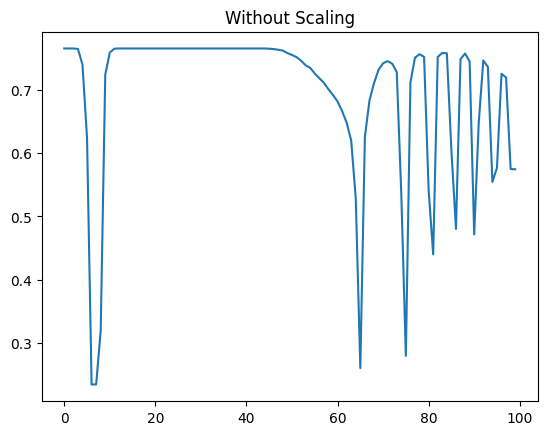

In [78]:
# Plot
plt.plot(val_acc_list)
plt.title("Without Scaling")
plt.show()

Epoch 0, Loss: 0.6526, Val Acc: 0.6807
Epoch 10, Loss: 0.6482, Val Acc: 0.6967
Epoch 20, Loss: 0.6440, Val Acc: 0.7077
Epoch 30, Loss: 0.6399, Val Acc: 0.7163
Epoch 40, Loss: 0.6361, Val Acc: 0.7270
Epoch 50, Loss: 0.6324, Val Acc: 0.7360
Epoch 60, Loss: 0.6288, Val Acc: 0.7427
Epoch 70, Loss: 0.6254, Val Acc: 0.7453
Epoch 80, Loss: 0.6221, Val Acc: 0.7497
Epoch 90, Loss: 0.6190, Val Acc: 0.7513
Epoch 100, Loss: 0.6160, Val Acc: 0.7543
Epoch 110, Loss: 0.6132, Val Acc: 0.7590
Epoch 120, Loss: 0.6104, Val Acc: 0.7593
Epoch 130, Loss: 0.6078, Val Acc: 0.7603
Epoch 140, Loss: 0.6052, Val Acc: 0.7620
Epoch 150, Loss: 0.6028, Val Acc: 0.7643
Epoch 160, Loss: 0.6004, Val Acc: 0.7643
Epoch 170, Loss: 0.5982, Val Acc: 0.7640
Epoch 180, Loss: 0.5960, Val Acc: 0.7643
Epoch 190, Loss: 0.5940, Val Acc: 0.7643
Epoch 200, Loss: 0.5920, Val Acc: 0.7640
Epoch 210, Loss: 0.5901, Val Acc: 0.7647


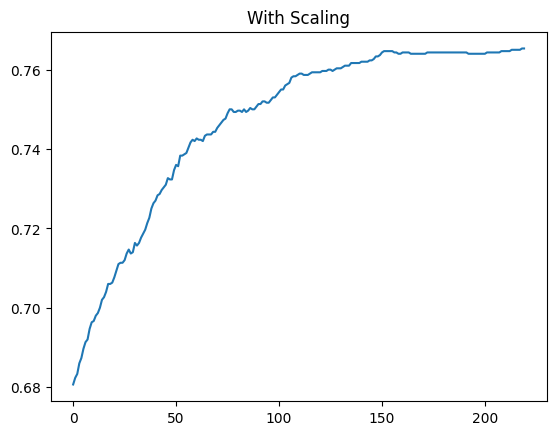

In [79]:
from sklearn.preprocessing import StandardScaler

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.numpy())
X_test_scaled = scaler.transform(X_test.numpy())

# Convert back to tensor
X_train_scaled = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_scaled = torch.tensor(X_test_scaled, dtype=torch.float32)

# New model
model = Model()

criterion = nn.BCELoss()
optimizer = optim.ASGD(model.parameters(), lr=0.001)

epochs = 220
val_acc_list_scaled = []

for epoch in range(epochs):
    # Forward
    outputs = model(X_train_scaled)
    loss = criterion(outputs, y_train)

    # Backward
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Validation
    with torch.no_grad():
        val_outputs = model(X_test_scaled)
        preds = (val_outputs > 0.5).float()
        acc = (preds == y_test).float().mean()
        val_acc_list_scaled.append(acc.item())

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}, Val Acc: {acc.item():.4f}")

# Plot
plt.plot(val_acc_list_scaled)
plt.title("With Scaling")
plt.show()